In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

# Set premium seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Create or get Spark Session
spark = SparkSession.builder.appName("sparksql").master("local[*]").getOrCreate()

HDFS_DIR = "hdfs://localhost:9000/data/"
LOCAL_DIR = "../Data/"

def load_dataset(filename):
    try:
        df = spark.read.option("header", "true") \
                        .option("inferSchema", "true") \
                        .option("multiLine", "true") \
                        .option("escape", '"') \
                        .csv(HDFS_DIR + filename)
        return df
    except Exception:
        df = spark.read.option("header", "true") \
                        .option("inferSchema", "true") \
                        .option("multiLine", "true") \
                        .option("escape", '"') \
                        .csv(LOCAL_DIR + filename)
        return df


orders = load_dataset("olist_orders_dataset.csv")
customers = load_dataset("olist_customers_dataset.csv")
order_items = load_dataset("olist_order_items_dataset.csv")
payments = load_dataset("olist_order_payments_dataset.csv")
reviews = load_dataset("olist_order_reviews_dataset.csv")
products = load_dataset("olist_products_dataset.csv")
sellers = load_dataset("olist_sellers_dataset.csv")
translation = load_dataset("product_category_name_translation.csv")

# Register Views for Spark SQL
orders.createOrReplaceTempView("orders")
customers.createOrReplaceTempView("customers")
order_items.createOrReplaceTempView("order_items")
payments.createOrReplaceTempView("payments")
reviews.createOrReplaceTempView("reviews")
products.createOrReplaceTempView("products")
sellers.createOrReplaceTempView("sellers")
translation.createOrReplaceTempView("translation")

Phân tích mức độ tập trung doanh thu theo Đối tác bán hàng (Seller) và Danh mục sản phẩm (Category).

+--------------------+------------------+------------------+--------------+
|           seller_id|           revenue|cumulative_revenue|cumulative_pct|
+--------------------+------------------+------------------+--------------+
|4869f7a5dfa277a7d...| 229472.6299999981| 229472.6299999981|          1.69|
|53243585a1d6dc264...|222776.04999999952| 452248.6799999976|          3.33|
|4a3ca9315b744ce9f...| 200472.9199999949| 652721.5999999925|           4.8|
|fa1c13f2614d7b5c4...|194042.02999999846|  846763.629999991|          6.23|
|7c67e1448b00f6e96...| 187923.8899999995|1034687.5199999905|          7.61|
|7e93a43ef30c4f03f...|176431.86999999982|1211119.3899999904|          8.91|
|da8622b14eb17ae28...|160236.56999999538|1371355.9599999858|         10.09|
|7a67c85e85bb2ce85...|141745.53000000177|1513101.4899999877|         11.13|
|1025f0e2d44d7041d...| 138968.5499999995|1652070.0399999872|         12.16|
|955fee9216a65b617...|135171.69999999914|1787241.7399999863|         13.15|
|46dc3b2cc09

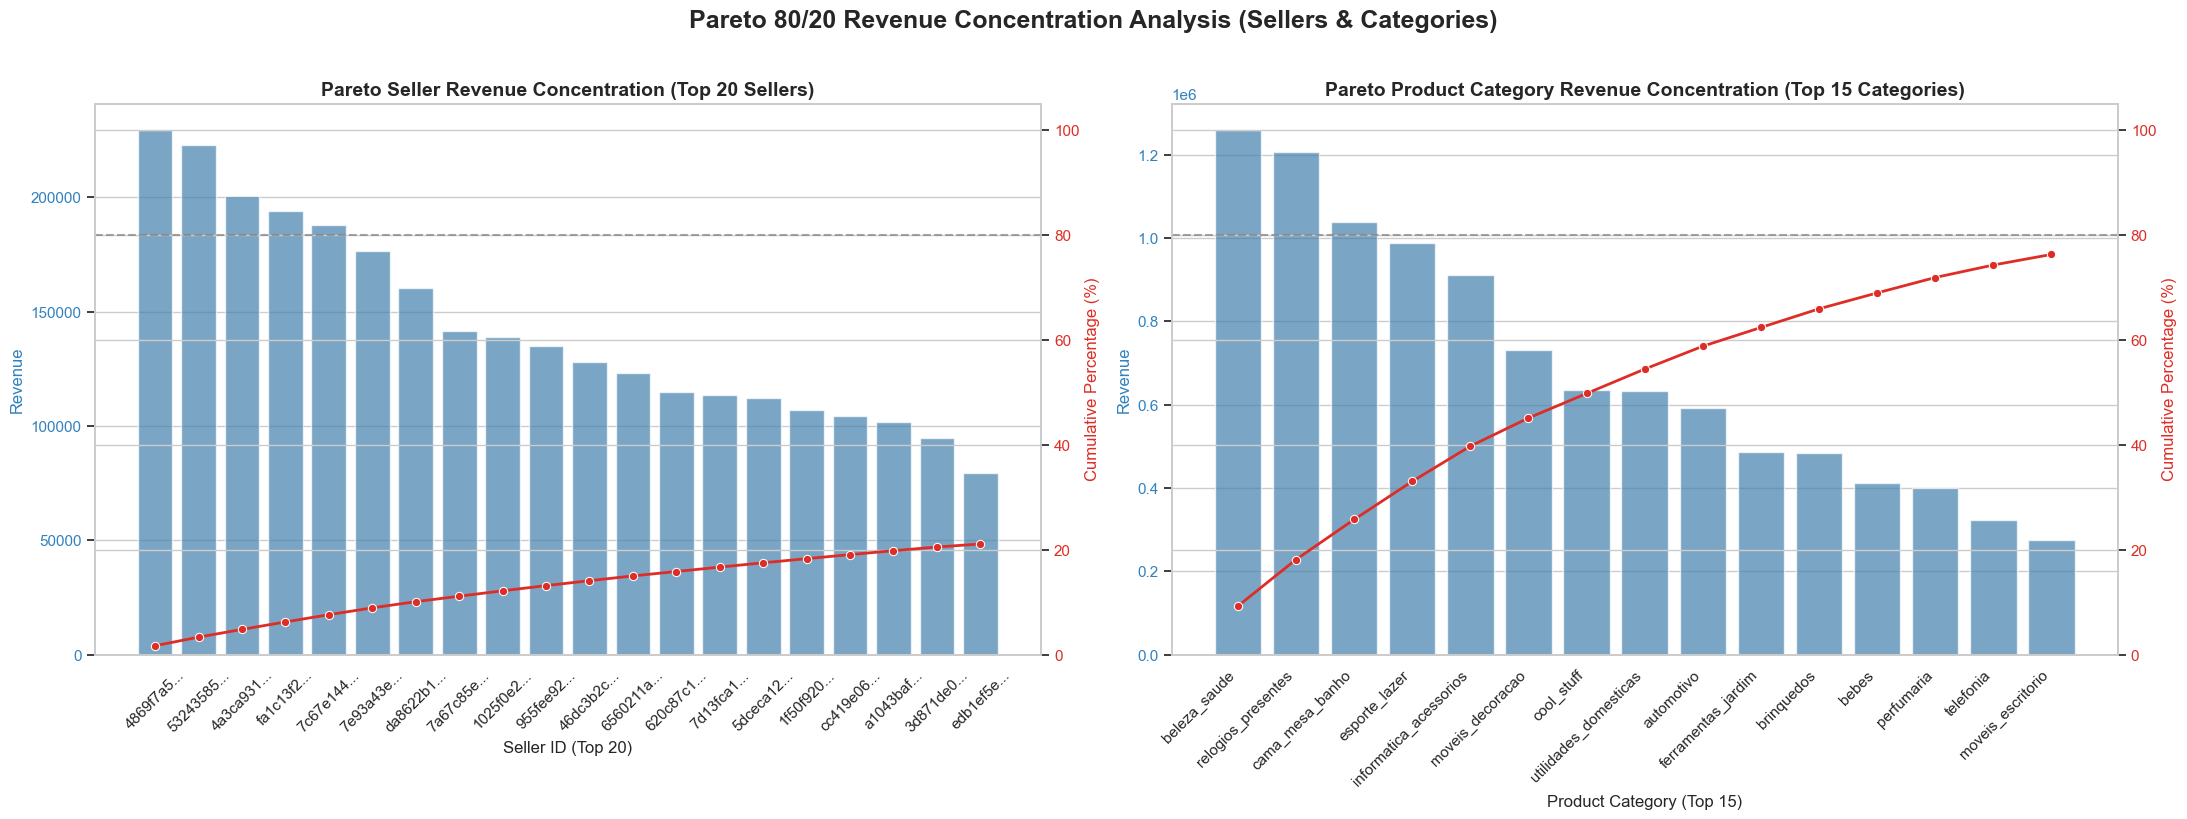

In [2]:
query_1 = spark.sql("""
WITH seller_revenue AS (
    SELECT seller_id, SUM(price) revenue
    FROM order_items
    GROUP BY seller_id
)

SELECT seller_id, revenue, SUM(revenue) OVER(ORDER BY revenue DESC) cumulative_revenue,
ROUND(SUM(revenue)OVER(ORDER BY revenue DESC)/SUM(revenue)OVER()*100,2) cumulative_pct
FROM seller_revenue
""")
query_1.show()

query_2 = spark.sql("""
WITH category_revenue AS (
    SELECT p.product_category_name, SUM(oi.price) revenue
    FROM order_items oi
    JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
)

SELECT *, ROUND(SUM(revenue) OVER(ORDER BY revenue DESC)/SUM(revenue) OVER()*100,2) cumulative_pct
FROM category_revenue
ORDER BY revenue DESC
""")
query_2.show()

# Visualize Pareto: Seller Revenue & Category Revenue Concentration side-by-side
pdf_1 = query_1.toPandas()
pdf_top_sellers = pdf_1.head(20)

pdf_2 = query_2.toPandas().dropna(subset=['product_category_name'])
pdf_top_cat = pdf_2.head(15)

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(22, 8))

# --- LEFT: Pareto Seller Revenue Analysis ---
color1 = '#3182bd'
ax1.set_xlabel('Seller ID (Top 20)', fontsize=12)
ax1.set_ylabel('Revenue', color=color1, fontsize=12)
short_seller_ids = pdf_top_sellers['seller_id'].apply(lambda x: x[:8] + '...')
sns.barplot(x=short_seller_ids, y='revenue', data=pdf_top_sellers, ax=ax1, color=color1, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(len(short_seller_ids))) 
ax1.set_xticklabels(short_seller_ids, rotation=45)

ax2 = ax1.twinx()
color2 = '#de2d26'
ax2.set_ylabel('Cumulative Percentage (%)', color=color2, fontsize=12)
sns.lineplot(x=range(len(pdf_top_sellers)), y='cumulative_pct', data=pdf_top_sellers, ax=ax2, color=color2, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax1.set_title("Pareto Seller Revenue Concentration (Top 20 Sellers)", fontsize=14, fontweight='bold')

# --- RIGHT: Revenue Concentration by Product Category ---
ax3.set_xlabel('Product Category (Top 15)', fontsize=12)
ax3.set_ylabel('Revenue', color=color1, fontsize=12)
sns.barplot(x='product_category_name', y='revenue', data=pdf_top_cat, ax=ax3, color=color1, alpha=0.7)
ax3.tick_params(axis='y', labelcolor=color1)
ax3.set_xticks(range(len(pdf_top_cat['product_category_name'])))
ax3.set_xticklabels(pdf_top_cat['product_category_name'], rotation=45, ha='right')

ax4 = ax3.twinx()
ax4.set_ylabel('Cumulative Percentage (%)', color=color2, fontsize=12)
sns.lineplot(x=range(len(pdf_top_cat)), y='cumulative_pct', data=pdf_top_cat, ax=ax4, color=color2, marker='o', linewidth=2)
ax4.tick_params(axis='y', labelcolor=color2)
ax4.set_ylim(0, 105)
ax4.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax3.set_title("Pareto Product Category Revenue Concentration (Top 15 Categories)", fontsize=14, fontweight='bold')

plt.suptitle("Pareto 80/20 Revenue Concentration Analysis (Sellers & Categories)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Khách hàng có dấu hiệu rời bỏ.

+--------------------+------------+------------------+
|  customer_unique_id|recency_days|      churn_status|
+--------------------+------------+------------------+
|0421e7a23f21e5d54...|           0|Active (0-30 days)|
|5c58de6fb80e93396...|           0|Active (0-30 days)|
|7febafa06d9d8f232...|           0|Active (0-30 days)|
|b4dcade04bc548b7e...|           0|Active (0-30 days)|
|afbcfd0b9c5233e7c...|           0|Active (0-30 days)|
|b701bebbdf478f550...|           0|Active (0-30 days)|
|f80013faf776e37bc...|           0|Active (0-30 days)|
|24ac2b4327e25baf3...|           0|Active (0-30 days)|
|21dbe8eabd00b3449...|           0|Active (0-30 days)|
|0c6d7218d5f3fa145...|           0|Active (0-30 days)|
+--------------------+------------+------------------+
only showing top 10 rows



C:\Users\USER\AppData\Local\Temp\ipykernel_32912\3909357192.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_counts.values, y=cohort_counts.index, palette='Oranges_r')


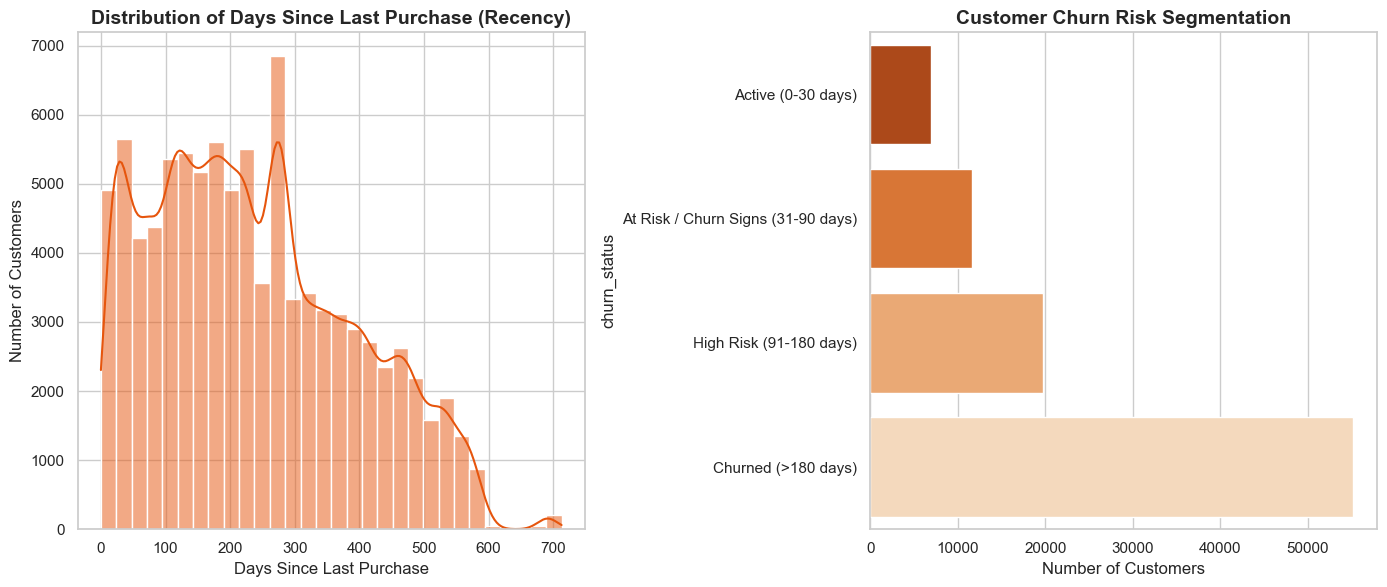

In [4]:
query_3 = """
WITH max_delivered_date AS (
    SELECT MAX(order_purchase_timestamp) as max_date 
    FROM orders 
    WHERE order_status = 'delivered'
),
customer_recency AS (
    SELECT c.customer_unique_id, MAX(o.order_purchase_timestamp) as last_purchase_date, DATEDIFF((SELECT max_date FROM max_delivered_date), MAX(o.order_purchase_timestamp)) as recency_days
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT 
    customer_unique_id, recency_days,
    CASE 
        WHEN recency_days <= 30 THEN 'Active (0-30 days)'
        WHEN recency_days BETWEEN 31 AND 90 THEN 'At Risk / Churn Signs (31-90 days)'
        WHEN recency_days BETWEEN 91 AND 180 THEN 'High Risk (91-180 days)'
        ELSE 'Churned (>180 days)'
    END as churn_status
FROM customer_recency
ORDER BY recency_days ASC
"""
df_3 = spark.sql(query_3)
df_3.show(10)

# Visualize Churn Signal (Recency Days & Cohort Distribution)
pdf_8 = df_3.toPandas()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(pdf_8['recency_days'], bins=30, kde=True, color='#e6550d')
plt.title("Distribution of Days Since Last Purchase (Recency)", fontsize=14, fontweight='bold')
plt.xlabel("Days Since Last Purchase", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.subplot(1, 2, 2)
cohort_counts = pdf_8['churn_status'].value_counts().reindex([
    'Active (0-30 days)', 
    'At Risk / Churn Signs (31-90 days)', 
    'High Risk (91-180 days)', 
    'Churned (>180 days)'
])
sns.barplot(x=cohort_counts.values, y=cohort_counts.index, palette='Oranges_r')
plt.title("Customer Churn Risk Segmentation", fontsize=14, fontweight='bold')
plt.xlabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

Impact of Delivery Delays on Review Scores

+----------------+------------+----------------+------------------+
|  delay_severity|total_orders|avg_review_score|pct_1_star_reviews|
+----------------+------------+----------------+------------------+
|On Time or Early|       89443|            4.29|              6.63|
|   1-7 Days Late|        3600|            2.71|             41.39|
|    >7 Days Late|        2781|             1.7|             69.68|
+----------------+------------+----------------+------------------+



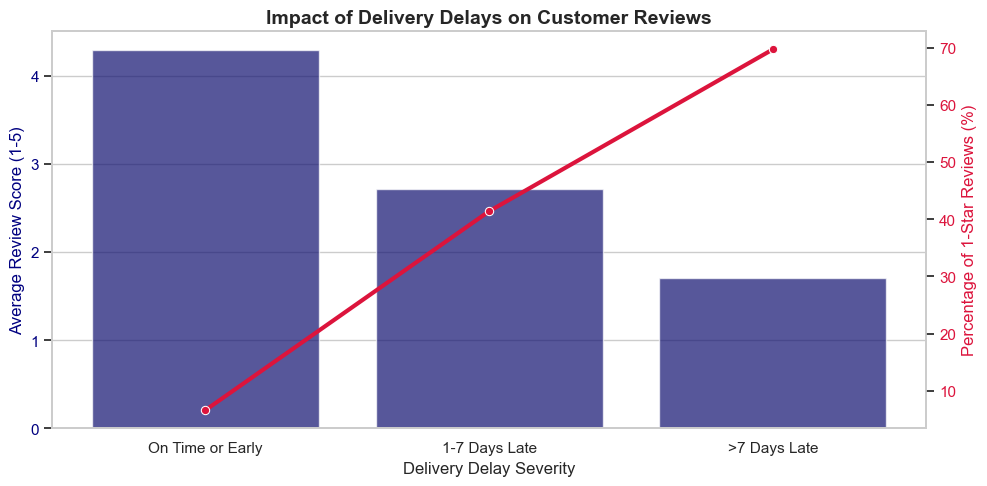

In [ ]:
query_4 = spark.sql("""
SELECT 
    CASE 
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) <= 0 THEN 'On Time or Early'
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) BETWEEN 1 AND 7 THEN '1-7 Days Late'
        ELSE '>7 Days Late'
    END as delay_severity,
    COUNT(DISTINCT o.order_id) as total_orders,
    ROUND(AVG(r.review_score), 2) as avg_review_score,
    ROUND(AVG(CASE WHEN r.review_score = 1 THEN 100 ELSE 0 END), 2) as pct_1_star_reviews
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY 1
ORDER BY avg_review_score DESC
""")
query_4.show()

# Visualize Impact of Delivery Delays on Reviews
pdf_4 = query_4.toPandas()
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'navy'
sns.barplot(data=pdf_4, x='delay_severity', y='avg_review_score', ax=ax1, color=color, alpha=0.7)
ax1.set_title('Impact of Delivery Delays on Customer Reviews', fontsize=14, fontweight='bold')
ax1.set_xlabel('Delivery Delay Severity', fontsize=12)
ax1.set_ylabel('Average Review Score (1-5)', fontsize=12, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'crimson'
sns.lineplot(data=pdf_4, x='delay_severity', y='pct_1_star_reviews', ax=ax2, color=color, marker='o', linewidth=3.0, sort=False)
ax2.set_ylabel('Percentage of 1-Star Reviews (%)', fontsize=12, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.tight_layout()
plt.show()

Thời gian giao hàng trung bình và tỉ lệ trễ theo từng tháng 

+--------------+----------------------+------------------------+-------------+------------------------+
|purchase_month|total_delivered_orders|avg_actual_delivery_days|late_rate_pct|avg_delay_days_when_late|
+--------------+----------------------+------------------------+-------------+------------------------+
|       2016-09|                     1|                    55.0|       100.00|                    36.0|
|       2016-10|                   265|                   19.63|         1.13|                    6.33|
|       2016-12|                     1|                     5.0|         0.00|                    NULL|
|       2017-01|                   750|                   12.75|         3.07|                   19.35|
|       2017-02|                  1653|                    13.3|         3.21|                   19.23|
|       2017-03|                  2546|                   13.04|         5.58|                   20.77|
|       2017-04|                  2303|                   15.02|

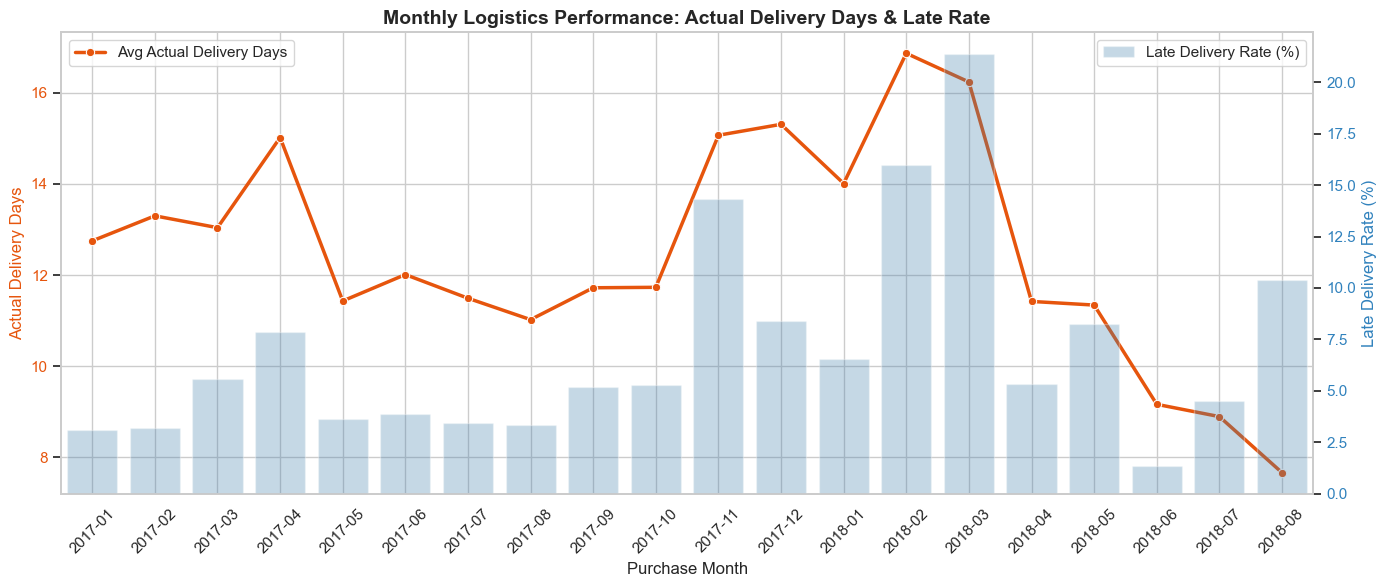

In [ ]:
query_5 = spark.sql("""
SELECT 
    DATE_FORMAT(order_purchase_timestamp, 'yyyy-MM') as purchase_month,
    COUNT(order_id) as total_delivered_orders,
    ROUND(AVG(DATEDIFF(order_delivered_customer_date, order_purchase_timestamp)), 2) as avg_actual_delivery_days,
    ROUND(SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(order_id), 2) as late_rate_pct,
    ROUND(AVG(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN DATEDIFF(order_delivered_customer_date, order_estimated_delivery_date) ELSE NULL END), 2) as avg_delay_days_when_late
FROM orders
WHERE order_status = 'delivered'
  AND order_purchase_timestamp IS NOT NULL
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
GROUP BY DATE_FORMAT(order_purchase_timestamp, 'yyyy-MM')
ORDER BY purchase_month ASC
""")
query_5.show(10)

# Visualize Monthly Logistics Performance
pdf_5 = query_5.toPandas()
pdf_plot = pdf_5[pdf_5['purchase_month'] >= '2017-01'].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Line plot for Actual Delivery Time
sns.lineplot(x='purchase_month', y='avg_actual_delivery_days', data=pdf_plot, ax=ax1, color='#e6550d', marker='o', linewidth=2.5, label='Avg Actual Delivery Days')
ax1.set_xlabel('Purchase Month', fontsize=12)
ax1.set_ylabel('Actual Delivery Days', color='#e6550d', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e6550d')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

# Bar plot for Late Delivery Rate on secondary axis
ax2 = ax1.twinx()
sns.barplot(x='purchase_month', y='late_rate_pct', data=pdf_plot, ax=ax2, color='#3182bd', alpha=0.3, label='Late Delivery Rate (%)')
ax2.set_ylabel('Late Delivery Rate (%)', color='#3182bd', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#3182bd')
ax2.grid(False)

plt.title("Monthly Logistics Performance: Actual Delivery Days & Late Rate", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Xác định khoảng cách thời gian (số ngày) giữa 2 lần mua hàng liên tiếp của mỗi khách hàng

+--------------------+------------------------+-------------------+-------------------+
|  customer_unique_id|order_purchase_timestamp|  previous_purchase|days_between_orders|
+--------------------+------------------------+-------------------+-------------------+
|004288347e5e88a27...|     2018-01-14 07:36:54|2017-07-27 14:13:03|                171|
|00a39521eb40f7012...|     2018-06-03 10:12:57|2018-05-23 20:14:21|                 11|
|013ef03e0f3f408dd...|     2018-07-20 04:13:54|2018-06-21 04:46:11|                 29|
|0178b244a5c281fb2...|     2018-07-28 13:13:00|2017-05-10 20:04:09|                444|
|031e19fc630c4121f...|     2018-07-04 01:20:01|2018-07-04 01:20:01|                  0|
|031ea691b99fc101d...|     2017-07-10 22:28:33|2017-05-16 13:42:51|                 55|
|032b3a42598667caf...|     2018-07-24 21:17:34|2018-07-23 15:11:08|                  1|
|0341bbd5c969923a0...|     2018-05-30 13:00:03|2018-05-28 14:18:26|                  2|
|0361e980b28826f4d...|     2018-

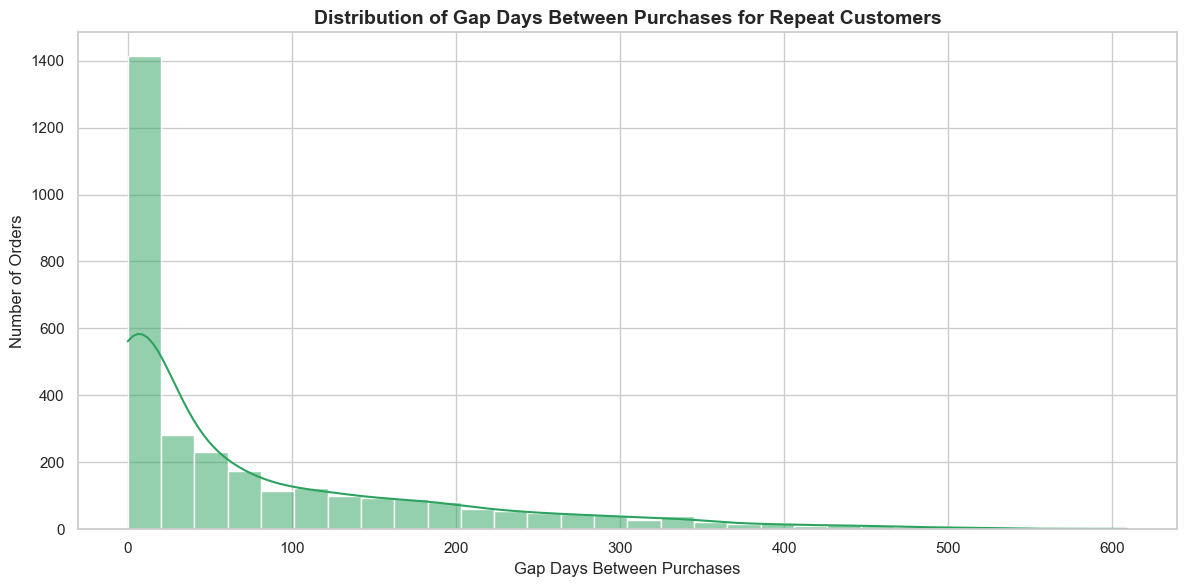

In [ ]:
query_6 = spark.sql("""
    WITH customer_purchase_sequences AS (
        SELECT 
            c.customer_unique_id,
            o.order_purchase_timestamp,
            LAG(o.order_purchase_timestamp) OVER (PARTITION BY c.customer_unique_id ORDER BY o.order_purchase_timestamp) as previous_purchase
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    )
    SELECT 
        customer_unique_id,
        order_purchase_timestamp,
        previous_purchase,
        DATEDIFF(order_purchase_timestamp, previous_purchase) as days_between_orders
    FROM customer_purchase_sequences
    WHERE previous_purchase IS NOT NULL
""")
query_6.show(10)

# Visualize purchase gap days distribution
pdf_6 = query_6.toPandas()
plt.figure(figsize=(12, 6))
sns.histplot(pdf_6['days_between_orders'], bins=30, kde=True, color='#2ca25f')
plt.title("Distribution of Gap Days Between Purchases for Repeat Customers", fontsize=14, fontweight='bold')
plt.xlabel("Gap Days Between Purchases", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.tight_layout()
plt.show()

Phân tích chi tiết các điểm nghẽn trong chu kỳ giao hàng (Thời gian duyệt đơn, thời gian người bán chuẩn bị hàng, và thời gian vận chuyển thực tế) để tìm ra khâu nào đang làm chậm trễ đơn hàng.

+--------------+----------------------+------------------+-----------------+----------------+-----------------------+
|purchase_month|total_delivered_orders|avg_approval_hours|avg_handling_days|avg_transit_days|avg_total_delivery_days|
+--------------+----------------------+------------------+-----------------+----------------+-----------------------+
|       2016-09|                     1|               0.0|            53.21|            1.61|                  54.81|
|       2016-10|                   265|             20.93|             13.0|            5.73|                   19.6|
|       2016-12|                     1|              0.25|             3.28|             1.4|                   4.69|
|       2017-01|                   748|              11.9|             2.94|             9.2|                  12.64|
|       2017-02|                  1641|               9.4|             3.24|            9.54|                  13.17|
|       2017-03|                  2546|              6.0

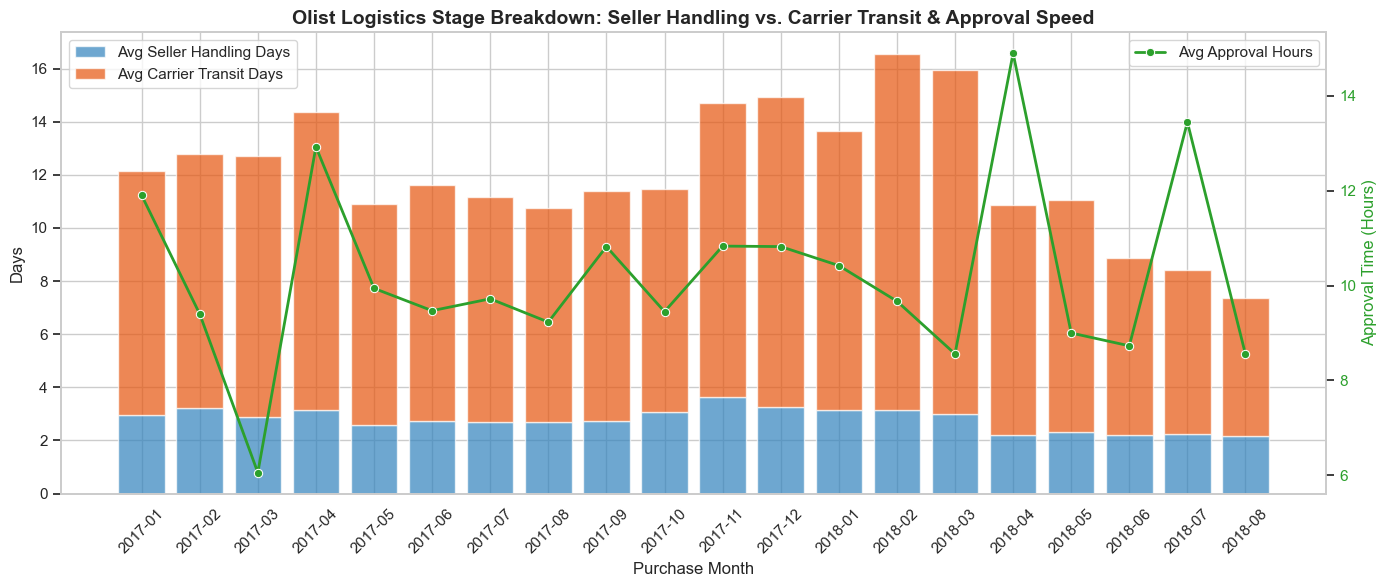

In [ ]:
query_7 = spark.sql("""
SELECT 
    DATE_FORMAT(order_purchase_timestamp, 'yyyy-MM') as purchase_month,
    COUNT(order_id) as total_delivered_orders,
    ROUND(AVG(unix_timestamp(order_approved_at) - unix_timestamp(order_purchase_timestamp)) / 3600.0, 2) as avg_approval_hours,
    ROUND(AVG(unix_timestamp(order_delivered_carrier_date) - unix_timestamp(order_approved_at)) / 86400.0, 2) as avg_handling_days,
    ROUND(AVG(unix_timestamp(order_delivered_customer_date) - unix_timestamp(order_delivered_carrier_date)) / 86400.0, 2) as avg_transit_days,
    ROUND(AVG(unix_timestamp(order_delivered_customer_date) - unix_timestamp(order_purchase_timestamp)) / 86400.0, 2) as avg_total_delivery_days
FROM orders
WHERE order_status = 'delivered'
  AND order_purchase_timestamp IS NOT NULL
  AND order_approved_at IS NOT NULL
  AND order_delivered_carrier_date IS NOT NULL
  AND order_delivered_customer_date IS NOT NULL
GROUP BY DATE_FORMAT(order_purchase_timestamp, 'yyyy-MM')
ORDER BY purchase_month ASC
""")
query_7.show(10)

# Visualize Logistics Stage Breakdown
pdf_7 = query_7.toPandas()
pdf_plot = pdf_7[pdf_7['purchase_month'] >= '2017-01'].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

months = pdf_plot['purchase_month'].values
handling = pdf_plot['avg_handling_days'].values
transit = pdf_plot['avg_transit_days'].values

# Stacked bar chart for day-based metrics (Seller Handling vs. Carrier Transit)
ax1.bar(months, handling, label='Avg Seller Handling Days', color='#3182bd', alpha=0.7)
ax1.bar(months, transit, bottom=handling, label='Avg Carrier Transit Days', color='#e6550d', alpha=0.7)
ax1.set_xlabel('Purchase Month', fontsize=12)
ax1.set_ylabel('Days', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

# Line chart for Approval Time in hours on secondary axis
ax2 = ax1.twinx()
sns.lineplot(x='purchase_month', y='avg_approval_hours', data=pdf_plot, ax=ax2, color='#2ca02c', marker='o', linewidth=2, label='Avg Approval Hours')
ax2.set_ylabel('Approval Time (Hours)', color='#2ca02c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.legend(loc='upper right')
ax2.grid(False)

plt.title("Olist Logistics Stage Breakdown: Seller Handling vs. Carrier Transit & Approval Speed", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tìm các khách hàng có tổng chi tiêu cao hơn mức chi tiêu trung bình của chính bang mà họ đang sinh sống

+--------------------+--------------+--------------+-------------+
|  customer_unique_id|customer_state|customer_spend|state_average|
+--------------------+--------------+--------------+-------------+
|62a459e5629b03dd7...|            AC|        1251.7|       257.71|
|086d6b5b5ba195a91...|            AC|        995.18|       257.71|
|3947ca729a860c522...|            AC|        905.93|       257.71|
|3e5c928acf49c4b95...|            AC|        861.26|       257.71|
|28989ef45087c96e5...|            AC|        723.15|       257.71|
|12e92c0f870fc6941...|            AC|        646.44|       257.71|
|22c739518f5240ffd...|            AC|         618.6|       257.71|
|0845d810b482f4d46...|            AC|        595.49|       257.71|
|c6bc2bf4b75f3f9da...|            AC|        591.88|       257.71|
|2ec67750cd5b98553...|            AC|        548.93|       257.71|
+--------------------+--------------+--------------+-------------+
only showing top 10 rows



C:\Users\USER\AppData\Local\Temp\ipykernel_36384\2729372376.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='vip_count', data=state_counts.head(15), palette='Blues_r')


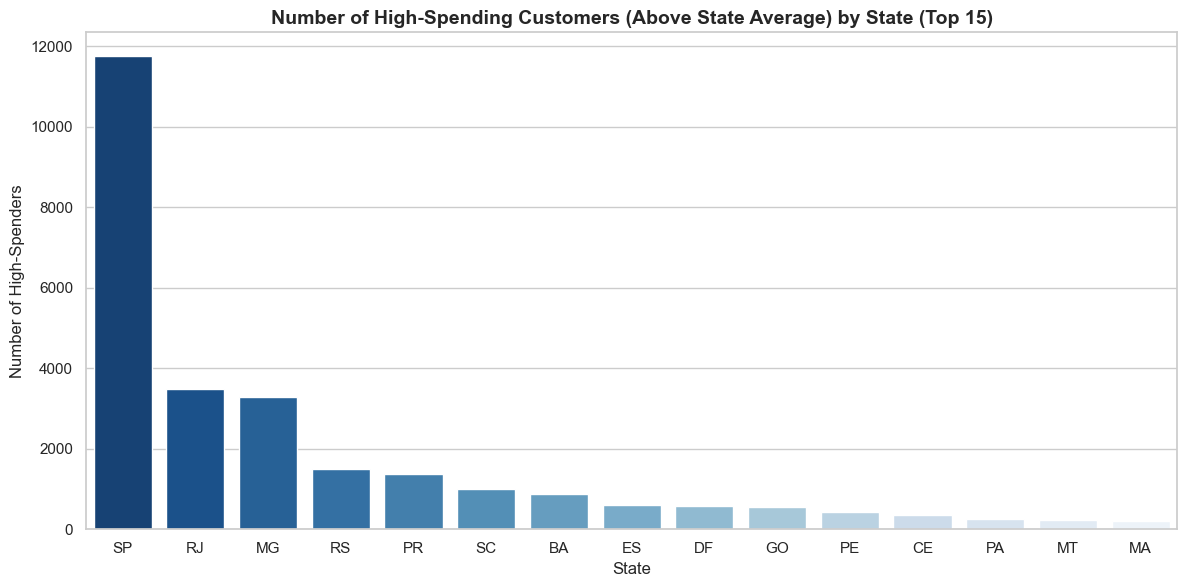

In [ ]:
query_8 = spark.sql("""
    WITH user_spend AS (
        SELECT c.customer_unique_id, c.customer_state, SUM(p.payment_value) as total_spend
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN payments p ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, c.customer_state
    ),
    state_avg_spend AS (
        SELECT customer_state, AVG(total_spend) as avg_state_spend
        FROM user_spend
        GROUP BY customer_state
    )
    SELECT u.customer_unique_id, u.customer_state, ROUND(u.total_spend, 2) as customer_spend, ROUND(s.avg_state_spend, 2) as state_average
    FROM user_spend u
    JOIN state_avg_spend s ON u.customer_state = s.customer_state
    WHERE u.total_spend > s.avg_state_spend
    ORDER BY u.customer_state, u.total_spend DESC
""")
query_8.show(10)

# Visualize VIP customer count per state
pdf_8 = query_8.toPandas()
state_counts = pdf_8.groupby('customer_state').size().reset_index(name='vip_count').sort_values(by='vip_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='customer_state', y='vip_count', data=state_counts.head(15), palette='Blues_r')
plt.title("Number of High-Spending Customers (Above State Average) by State (Top 15)", fontsize=14, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of High-Spenders", fontsize=12)
plt.tight_layout()
plt.show()

Đánh giá mối tương quan giữa số kỳ trả góp (Installments) và điểm đánh giá (Review Score)

+--------------------+------------+----------------+
|payment_installments|total_orders|avg_review_score|
+--------------------+------------+----------------+
|                   1|       25238|            4.15|
|                   2|       12293|            4.11|
|                   3|       10355|            4.06|
|                   4|        7042|            4.05|
|                   5|        5188|            4.06|
|                   6|        3881|            4.08|
|                   7|        1607|            4.04|
|                   8|        4222|            4.02|
|                   9|         634|            4.08|
|                  10|        5261|            3.96|
|                  12|         131|            3.95|
+--------------------+------------+----------------+



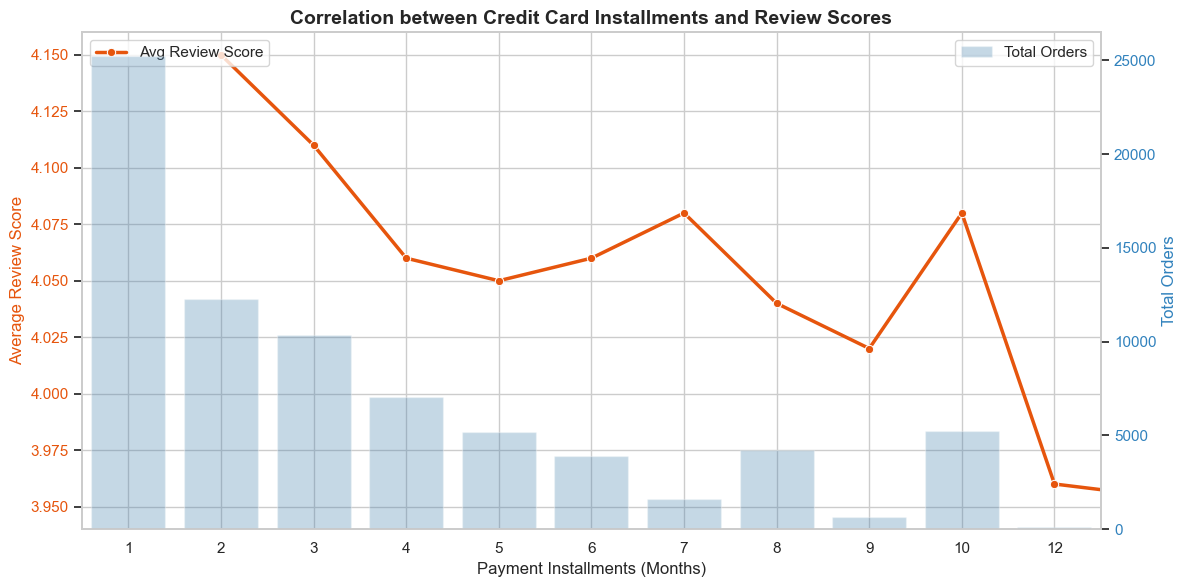

In [ ]:
query_9 = spark.sql("""
    SELECT 
        p.payment_installments,
        COUNT(DISTINCT o.order_id) as total_orders,
        ROUND(AVG(r.review_score), 2) as avg_review_score
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    JOIN reviews r ON o.order_id = r.order_id
    WHERE p.payment_type = 'credit_card'
    GROUP BY p.payment_installments
    HAVING COUNT(DISTINCT o.order_id) > 100
    ORDER BY p.payment_installments
""")
query_9.show()

# Visualize Installments and Review Scores
pdf_9 = query_9.toPandas()
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(x='payment_installments', y='avg_review_score', data=pdf_9, ax=ax1, color='#e6550d', marker='o', linewidth=2.5, label='Avg Review Score')
ax1.set_xlabel('Payment Installments (Months)', fontsize=12)
ax1.set_ylabel('Average Review Score', color='#e6550d', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e6550d')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.barplot(x='payment_installments', y='total_orders', data=pdf_9, ax=ax2, color='#3182bd', alpha=0.3, label='Total Orders')
ax2.set_ylabel('Total Orders', color='#3182bd', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#3182bd')
ax2.grid(False)

plt.title("Correlation between Credit Card Installments and Review Scores", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Chỉ kiểm tra những đơn hàng được giao đúng hạn hoặc sớm hơn, để có thể phân biệt các vấn đề về chất lượng sản phẩm và mô tả với các vấn đề về chậm trễ giao hàng.

+--------------------+-------------+----------------+--------------+
|    category_english|total_reviews|avg_review_score|bad_review_pct|
+--------------------+-------------+----------------+--------------+
|    office_furniture|         1508|            3.61|          22.4|
|     fixed_telephony|          242|            3.82|          21.1|
|        home_confort|          383|            4.01|          16.2|
|construction_tool...|          172|            4.04|          15.7|
|      bed_bath_table|         9938|            4.05|          14.7|
|   home_construction|          543|            4.06|          14.5|
|furniture_living_...|          453|            4.07|          13.2|
|     furniture_decor|         7407|            4.08|          14.7|
|             unknown|         1384|             4.1|          15.1|
|computers_accesso...|         7025|            4.11|          13.9|
|               audio|          313|            4.11|          14.4|
|           telephony|         403

C:\Users\USER\AppData\Local\Temp\ipykernel_36384\2677239490.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='avg_review_score', y='category_english', data=pdf_10, palette='Reds_r')


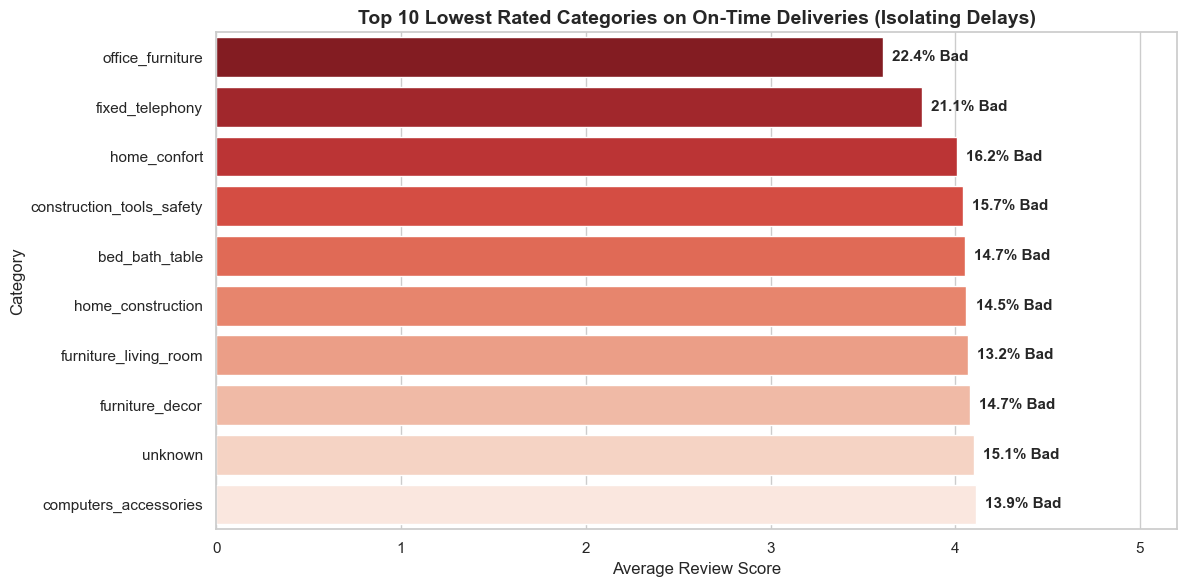

In [ ]:
query_10 = spark.sql("""
SELECT 
    COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') as category_english,
    COUNT(r.review_score) as total_reviews,
    ROUND(AVG(r.review_score), 2) as avg_review_score,
    ROUND(AVG(CASE WHEN r.review_score <= 2 THEN 100 ELSE 0 END), 1) as bad_review_pct
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN (SELECT order_id, AVG(review_score) as review_score FROM reviews GROUP BY 1) r USING(order_id)
LEFT JOIN translation t USING(product_category_name)
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date <= o.order_estimated_delivery_date
GROUP BY 1
HAVING total_reviews > 150
ORDER BY avg_review_score ASC
""")
query_10.show()

# Visualize Lowest Rated Categories on On-Time Deliveries
pdf_10 = query_10.toPandas().head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='avg_review_score', y='category_english', data=pdf_10, palette='Reds_r')
plt.title("Top 10 Lowest Rated Categories on On-Time Deliveries (Isolating Delays)", fontsize=14, fontweight='bold')
plt.xlabel("Average Review Score", fontsize=12)
plt.ylabel("Category", fontsize=12)

# Annotate the bad review percentage on the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    pct = pdf_10.iloc[i]['bad_review_pct']
    ax.text(width + 0.05, p.get_y() + p.get_height()/2, f"{pct:.1f}% Bad", va='center', fontweight='bold')

plt.xlim(0, 5.2)
plt.tight_layout()
plt.show()

Phân loại đối tác theo số ngày hoạt động trên nền tảng và tính toán tỷ lệ rời bỏ

+--------------------+------------+----------+-----------+--------------+
|       seller_cohort|seller_count|avg_orders|avg_revenue|churn_rate_pct|
+--------------------+------------+----------+-----------+--------------+
|        1-day Seller|         543|       1.0|      251.4|          65.4|
|Short-lived (1-30...|         289|       3.9|     597.39|          42.6|
|Medium-lived (31-...|         972|      10.9|    1804.78|          40.1|
|Long-lived (>180 ...|        1166|      73.4|    9569.55|          26.8|
+--------------------+------------+----------+-----------+--------------+



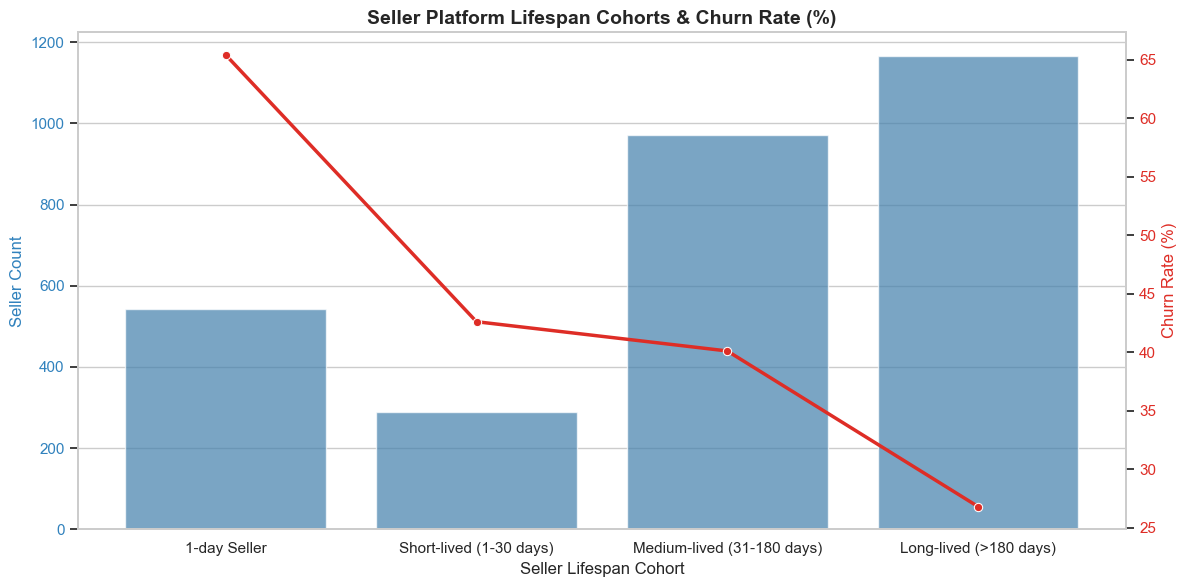

In [ ]:
query_11 = spark.sql("""
WITH seller_stats AS (
    SELECT  seller_id, COUNT(DISTINCT o.order_id) as total_orders, SUM(oi.price) as total_revenue,
        DATEDIFF(MAX(o.order_purchase_timestamp), MIN(o.order_purchase_timestamp)) as active_days,
        DATEDIFF('2018-09-01 00:00:00', MAX(o.order_purchase_timestamp)) as days_since_last_sale
    FROM order_items oi
    JOIN orders o USING(order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY seller_id
)
SELECT 
    CASE 
        WHEN active_days = 0 THEN '1-day Seller'
        WHEN active_days <= 30 THEN 'Short-lived (1-30 days)'
        WHEN active_days <= 180 THEN 'Medium-lived (31-180 days)'
        ELSE 'Long-lived (>180 days)'
    END as seller_cohort,
    COUNT(*) as seller_count,
    ROUND(AVG(total_orders), 1) as avg_orders,
    ROUND(AVG(total_revenue), 2) as avg_revenue,
    ROUND(AVG(CASE WHEN days_since_last_sale > 90 THEN 100 ELSE 0 END), 1) as churn_rate_pct
FROM seller_stats
GROUP BY 1
ORDER BY avg_revenue ASC
""")
query_11.show()

# Visualize Seller Cohort Distribution & Churn Rate (%)
pdf_11 = query_11.toPandas()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for seller count
sns.barplot(x='seller_cohort', y='seller_count', data=pdf_11, ax=ax1, color='#3182bd', alpha=0.7)
ax1.set_xlabel('Seller Lifespan Cohort', fontsize=12)
ax1.set_ylabel('Seller Count', color='#3182bd', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3182bd')

# Line plot for churn rate
ax2 = ax1.twinx()
sns.lineplot(x='seller_cohort', y='churn_rate_pct', data=pdf_11, ax=ax2, color='#de2d26', marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel('Churn Rate (%)', color='#de2d26', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#de2d26')
ax2.grid(False)

plt.title("Seller Platform Lifespan Cohorts & Churn Rate (%)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Xác định các cặp sản phẩm thuộc cùng một danh mục thường được mua trong cùng một giỏ hàng

+--------------------+-----------------+---------+
|          category_a|       category_b|frequency|
+--------------------+-----------------+---------+
|      bed_bath_table|  furniture_decor|       70|
|      bed_bath_table|     home_confort|       43|
|     furniture_decor|       housewares|       24|
|                baby|       cool_stuff|       20|
|      bed_bath_table|       housewares|       20|
|                baby|             toys|       19|
|     furniture_decor|     garden_tools|       17|
|                baby|   bed_bath_table|       17|
|          housewares|          unknown|       14|
|       health_beauty|   sports_leisure|       14|
|     furniture_decor|home_construction|       13|
|       health_beauty|        perfumery|       12|
|                baby|  furniture_decor|       12|
|        garden_tools|       housewares|       11|
|construction_tool...|  furniture_decor|       11|
+--------------------+-----------------+---------+



C:\Users\USER\AppData\Local\Temp\ipykernel_36384\3456651255.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='pair', data=pdf_12, palette='Purples_r')


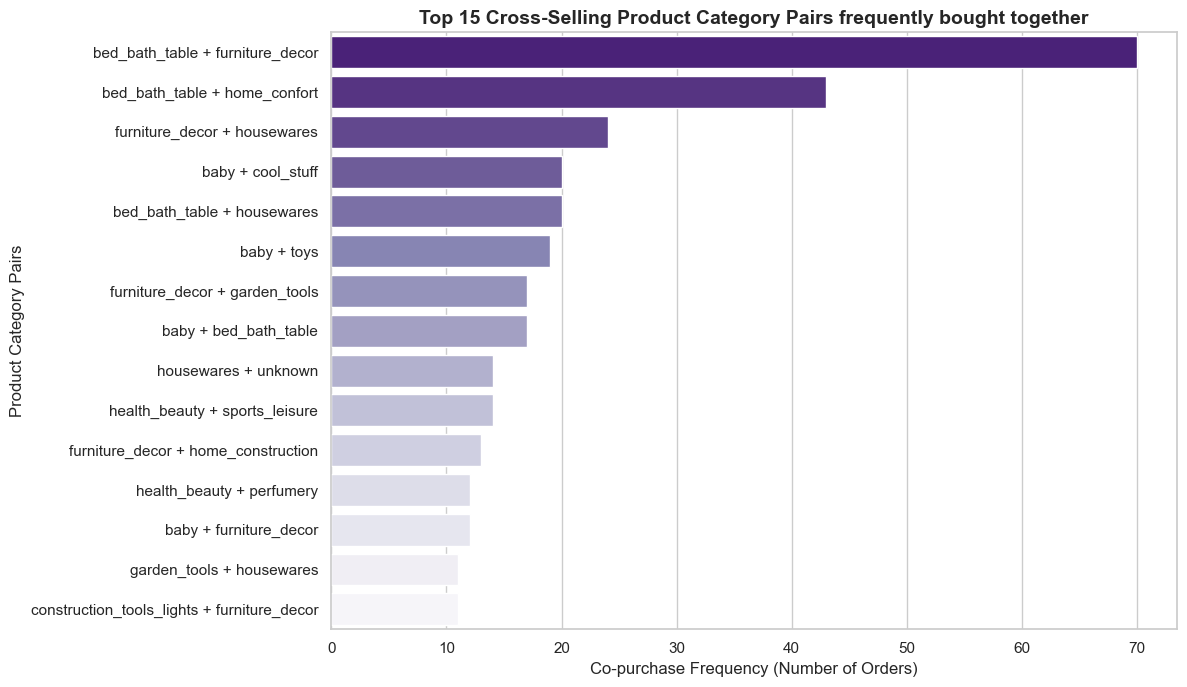

In [ ]:
query_12 = spark.sql("""
WITH order_categories AS (
    SELECT DISTINCT oi.order_id, COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') as category
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN translation t ON p.product_category_name = t.product_category_name
)
SELECT 
    c1.category as category_a,
    c2.category as category_b,
    COUNT(*) as frequency
FROM order_categories c1
JOIN order_categories c2 ON c1.order_id = c2.order_id
WHERE c1.category < c2.category
GROUP BY c1.category, c2.category
ORDER BY frequency DESC
LIMIT 15
""")
query_12.show()

# Visualize Top Category Pairs frequently bought together
pdf_12 = query_12.toPandas()
pdf_12['pair'] = pdf_12['category_a'] + ' + ' + pdf_12['category_b']

plt.figure(figsize=(12, 7))
sns.barplot(x='frequency', y='pair', data=pdf_12, palette='Purples_r')
plt.title("Top 15 Cross-Selling Product Category Pairs frequently bought together", fontsize=14, fontweight='bold')
plt.xlabel("Co-purchase Frequency (Number of Orders)", fontsize=12)
plt.ylabel("Product Category Pairs", fontsize=12)
plt.tight_layout()
plt.show()